# Optimization analysis

How everything is broken :)

In [1]:
# Create virtual environment and install dependencies
# For Windows
# !python -m venv venv
# !venv\Scripts\activate && pip install -r jupyter_dependencies.txt

# For Unix or MacOS (uncomment and use if needed)
# !python3 -m venv venv
# !source venv/bin/activate && pip install -r jupyter_requirements.txt


## Cleaning output file

Extract lines with the parameter values and the error to `output_M_5P.txt`.

In [19]:
import re
import csv

input_file = 'output/output.txt'
output_file = 'output.csv'
output_collagen_file = 'collagen_fibroblast.csv'

param_names = []
param_row_pattern = re.compile(r'^\s*(\d+)((?:\s+\d+:\s*-?\d+\.\d+)+)\s+(-?\d+\.\d+)\s*$')
param_pattern = re.compile(r"\[(.*?)\]")
iteration_pattern = re.compile(r'Running iteration (\d+)')
day_pattern = re.compile(
    r'Day (\d+): collagen=(\d+) activated=(\d+) fibroblasts=(\d+)'
)

rows = []
collagen_rows = []

with open(input_file, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i]
    # Extract parameter names
    if line.strip().startswith('[') and 'x' in line:
        match = param_pattern.search(line)
        if match:
            candidate_names = [x.strip().strip("'\"") for x in match.group(1).split(',')]
            # Only accept if all names start with 'x'
            if all(name.startswith('x') for name in candidate_names):
                param_names = candidate_names
                print(f"Extracted parameter names: {param_names}")
    # Extract parameter row
    m = param_row_pattern.match(line)
    if m:
        idx = int(m.group(1))
        values = [float(val) for val in re.findall(r':\s*(-?\d+\.\d+)', m.group(2))]
        error = float(m.group(3))
        rows.append([idx] + values + [error])

        # Now, look ahead for collagen/fibroblast blocks
        j = i + 1
        while j < len(lines):
            # Stop if next parameter row is found
            if param_row_pattern.match(lines[j]):
                break
            # Look for Day 3 and Day 6 lines
            day3 = day_pattern.match(lines[j].strip())
            day6 = day_pattern.match(lines[j+1].strip()) if (j+1) < len(lines) else None
            if day3 and day6:
                # Day 3
                collagen_rows.append([
                    idx, None, 3,  # You can fill in iteration if available elsewhere
                    int(day3.group(2)), int(day3.group(3)), int(day3.group(4))
                ])
                # Day 6
                collagen_rows.append([
                    idx, None, 6,
                    int(day6.group(2)), int(day6.group(3)), int(day6.group(4))
                ])
                j += 2
            else:
                j += 1
        i = j - 1  # Move to just before next param row
    i += 1

# Write parameter CSV
if not param_names:
    raise ValueError("Parameter names not found in file.")

header = ['index'] + param_names + ['error']
with open(output_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    for row in rows:
        writer.writerow(row)

# Write collagen/fibroblast CSV
collagen_header = ['param_index', 'iteration', 'day', 'collagen', 'activated', 'fibroblasts']
with open(output_collagen_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(collagen_header)
    for row in collagen_rows:
        writer.writerow(row)

print(f"Wrote {len(rows)} parameter rows to {output_file}")
print(f"Wrote {len(collagen_rows)} collagen/fibroblast rows to {output_collagen_file}")

Extracted parameter names: ['x38', 'x18', 'x25', 'x24', 'x16', 'x43', 'x8', 'x66', 'x37', 'x12', 'x10', 'x7', 'x6', 'x45', 'x54', 'x47', 'x27', 'x14', 'x33', 'x2', 'x31', 'x46', 'x28', 'x41', 'x57', 'x23', 'x63', 'x26', 'x69', 'x58', 'x51', 'x73', 'x30', 'x67', 'x68', 'x48', 'x44', 'x32', 'x0', 'x4']
Wrote 91 parameter rows to output.csv
Wrote 1620 collagen/fibroblast rows to collagen_fibroblast.csv


In [20]:
import pandas as pd
pd.set_option('display.max_columns', None)

output_df = pd.read_csv('output.csv')
print(output_df.head())

   index   x38   x18   x25   x24   x16  x43   x8  x66  x37   x12  x10   x7  \
0      1   0.1   0.1   0.1   0.5  0.02  0.0  0.1  0.0  1.0  50.0  0.1  0.1   
1      2  10.0   0.1   0.1   0.5  0.02  0.0  0.1  0.0  1.0  50.0  0.1  0.1   
2      3   0.1  10.0   0.1   0.5  0.02  0.0  0.1  0.0  1.0  50.0  0.1  0.1   
3      4   0.1   0.1  10.0   0.5  0.02  0.0  0.1  0.0  1.0  50.0  0.1  0.1   
4      5   0.1   0.1   0.1  50.0  0.02  0.0  0.1  0.0  1.0  50.0  0.1  0.1   

      x6     x45    x54  x47  x27  x14  x33   x2  x31  x46  x28  x41  x57  \
0  0.001  1420.0  140.0  0.0  2.5  2.5  1.0  1.0  5.0  0.0  0.2  5.0  6.6   
1  0.001  1420.0  140.0  0.0  2.5  2.5  1.0  1.0  5.0  0.0  0.2  5.0  6.6   
2  0.001  1420.0  140.0  0.0  2.5  2.5  1.0  1.0  5.0  0.0  0.2  5.0  6.6   
3  0.001  1420.0  140.0  0.0  2.5  2.5  1.0  1.0  5.0  0.0  0.2  5.0  6.6   
4  0.001  1420.0  140.0  0.0  2.5  2.5  1.0  1.0  5.0  0.0  0.2  5.0  6.6   

   x23  x63  x26  x69   x58   x51    x73  x30  x67  x68   x48  x44  

## Performance

In [ ]:
min_error = output_df['error'].min()

print("Original error: ", output_df.iloc[0]['error'])
print("Final error: ", output_df.iloc[-1]['error'])
print("Minimum error: ", min_error)
print("Percentage decrease: ", ((output_df.iloc[0]['error'] - min_error) / output_df.iloc[0]['error']) * 100)

Original error:  3.822317
Minimum error:  3.409723
Percentage decrease:  10.794342803069444


## Parameters

Change in parameter values.



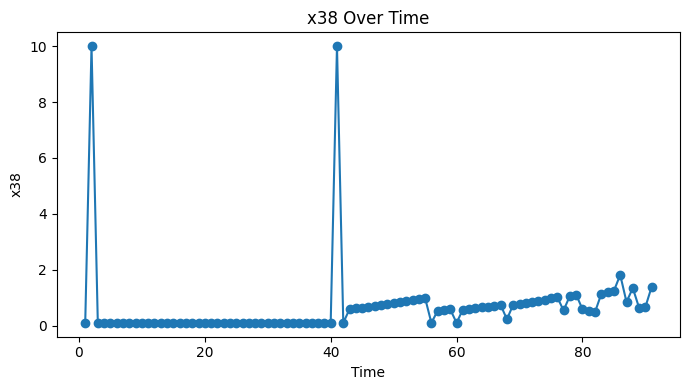

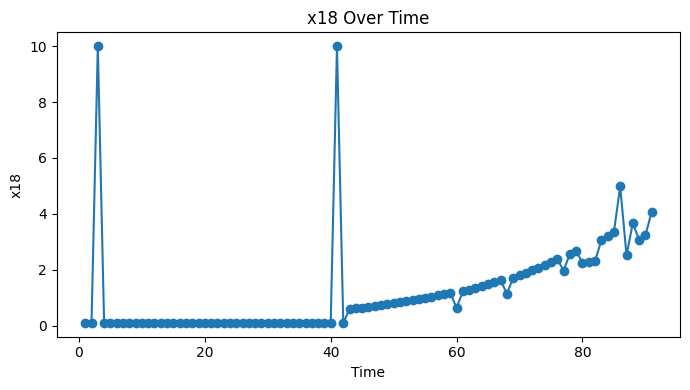

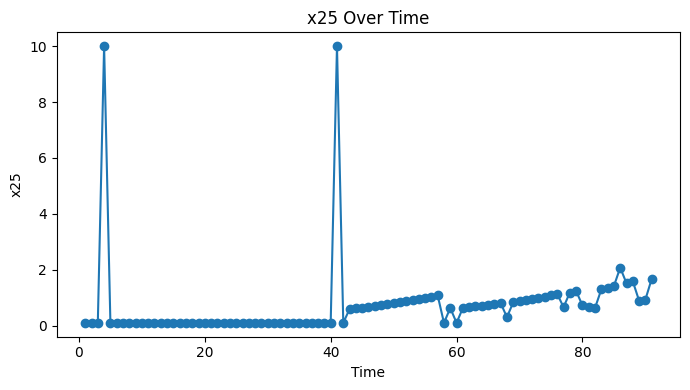

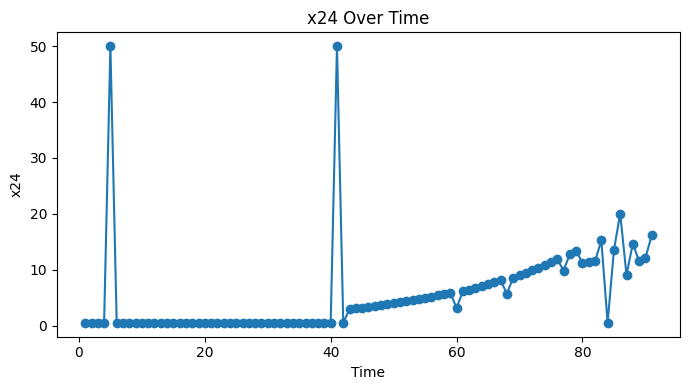

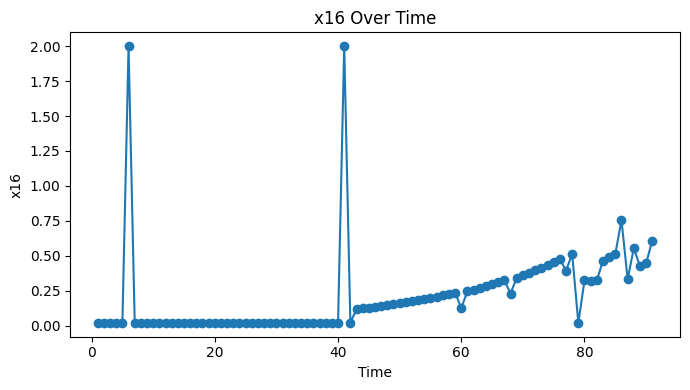

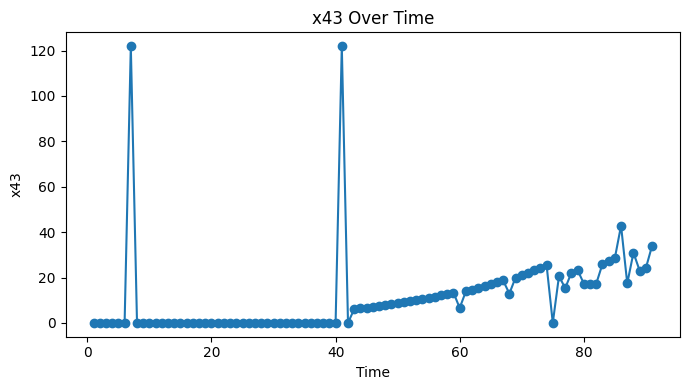

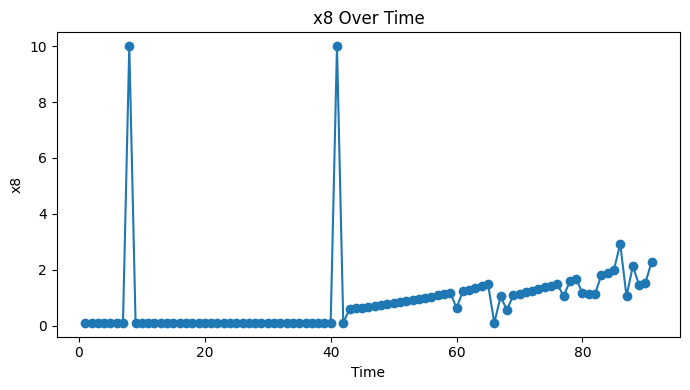

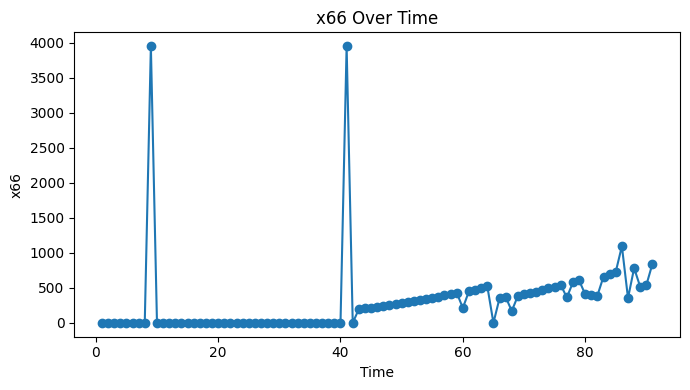

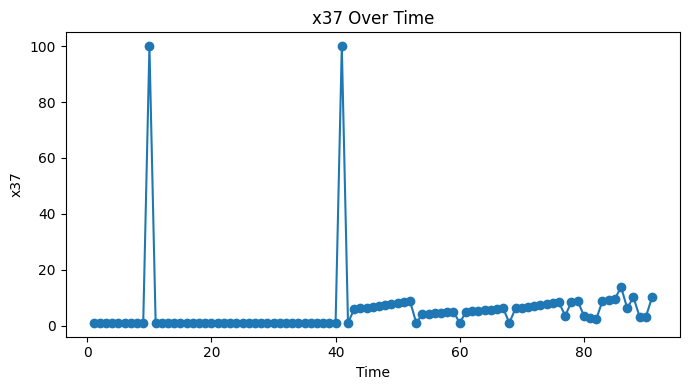

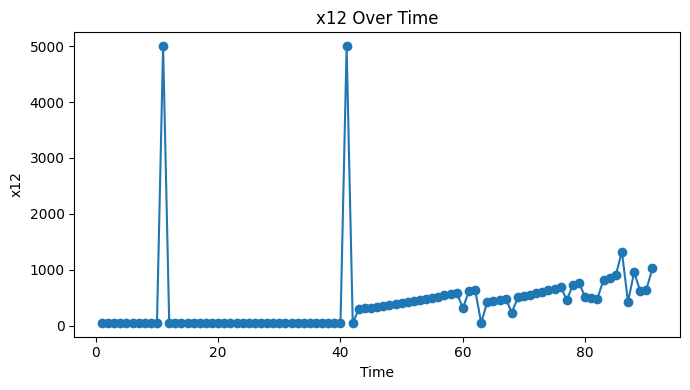

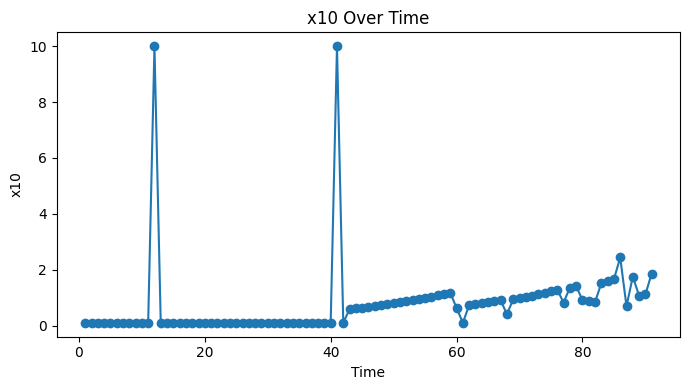

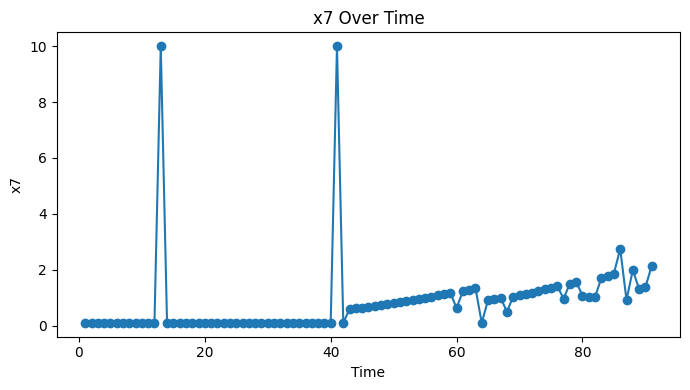

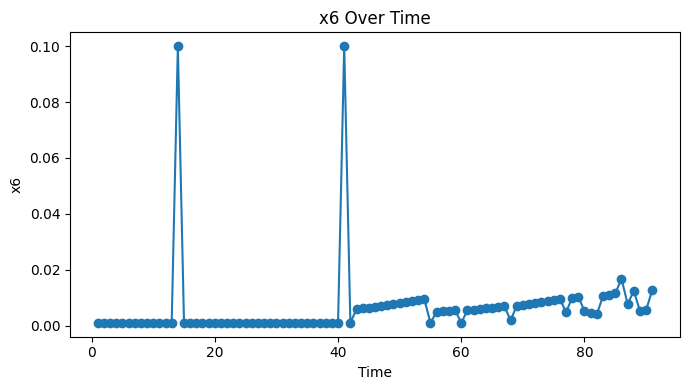

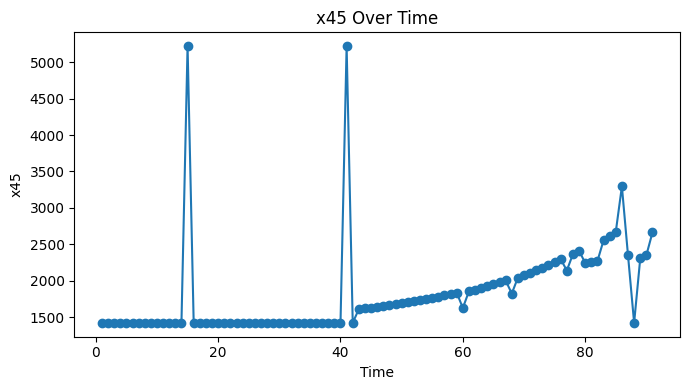

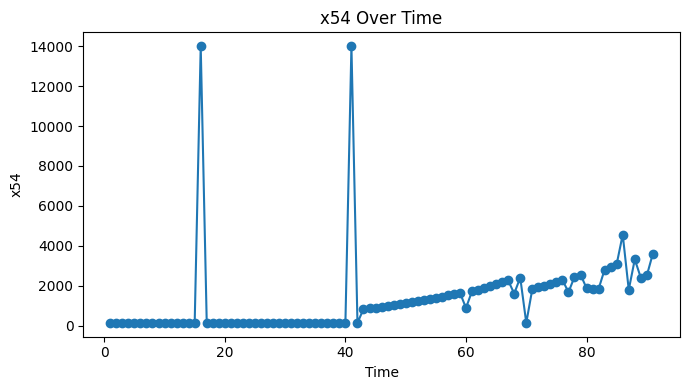

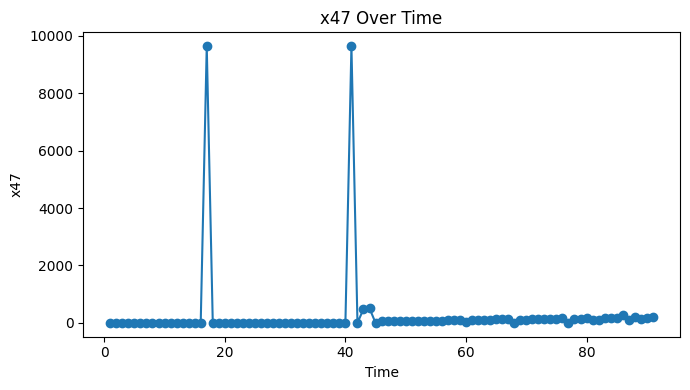

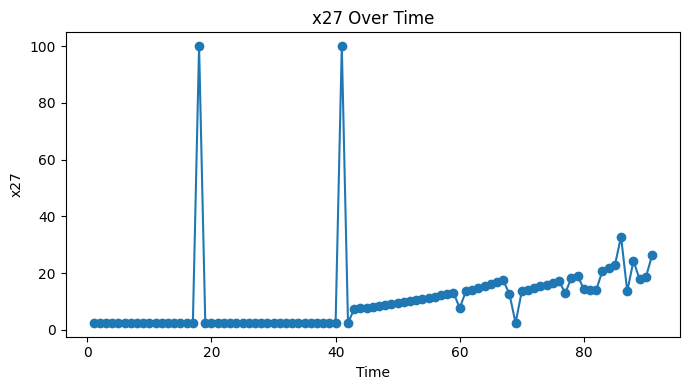

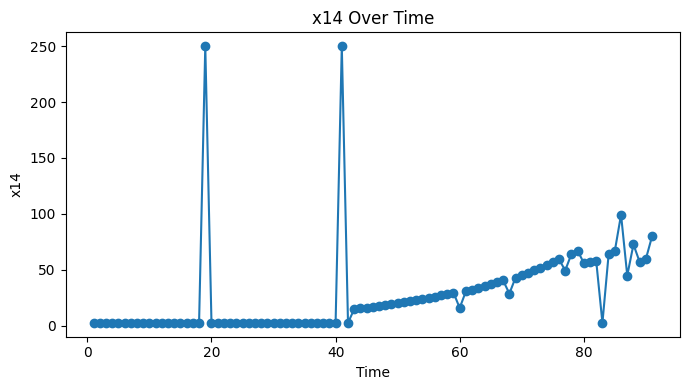

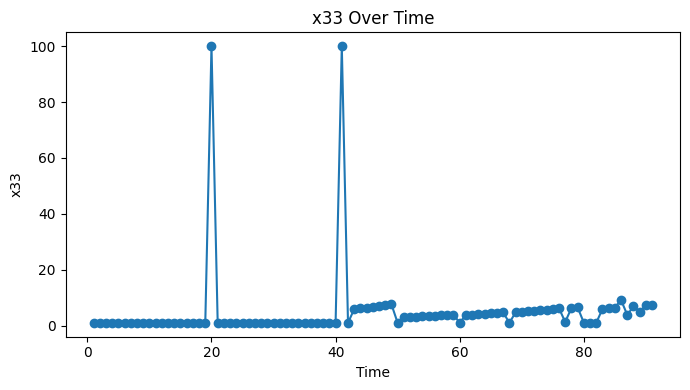

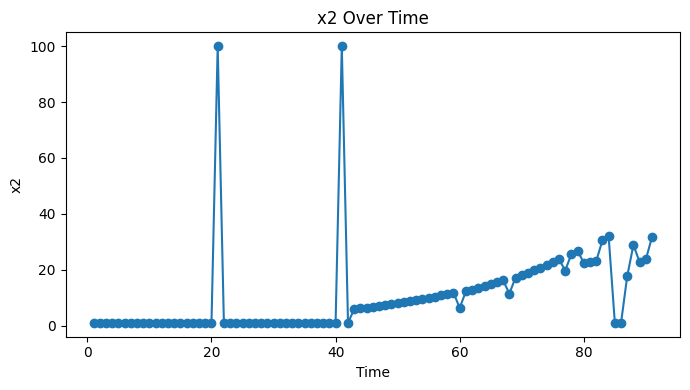

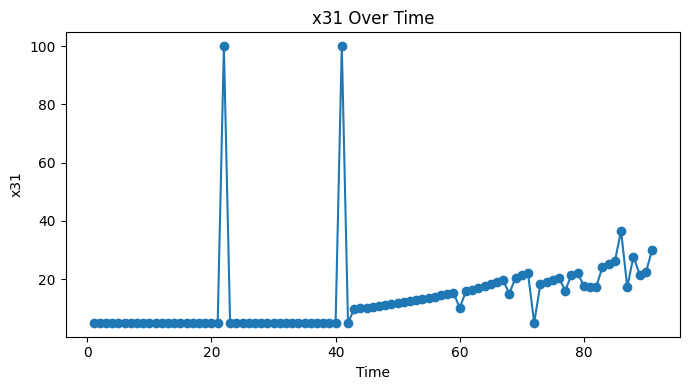

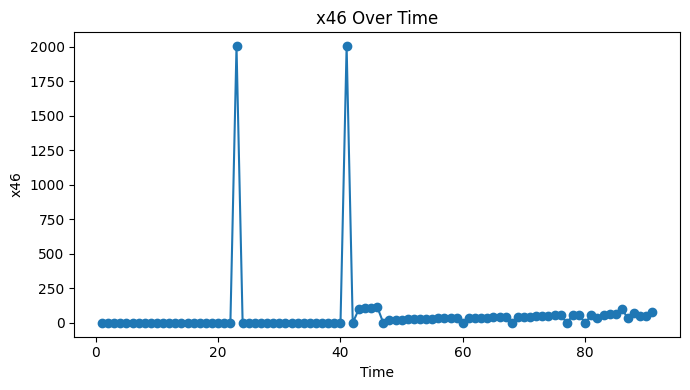

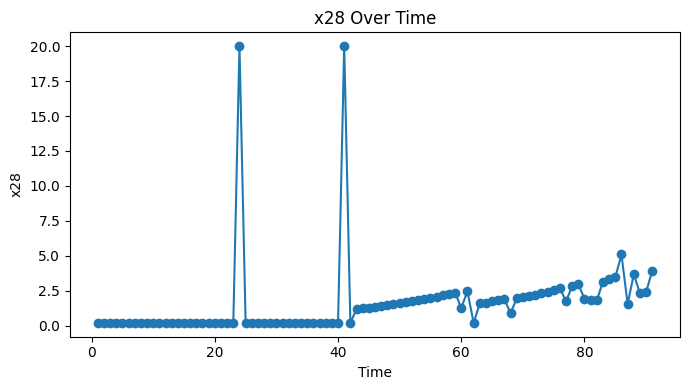

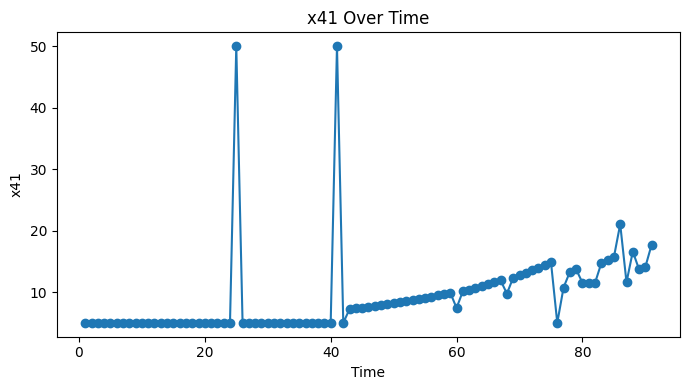

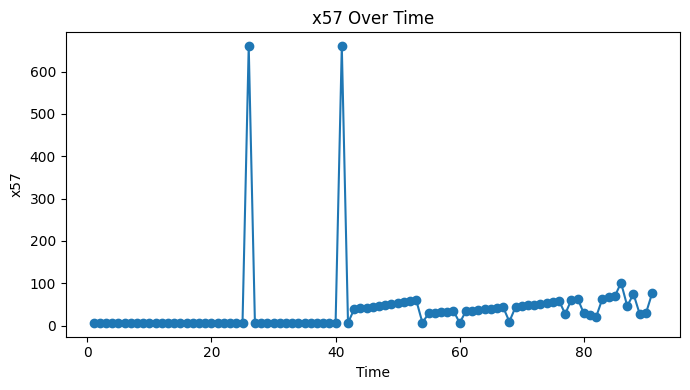

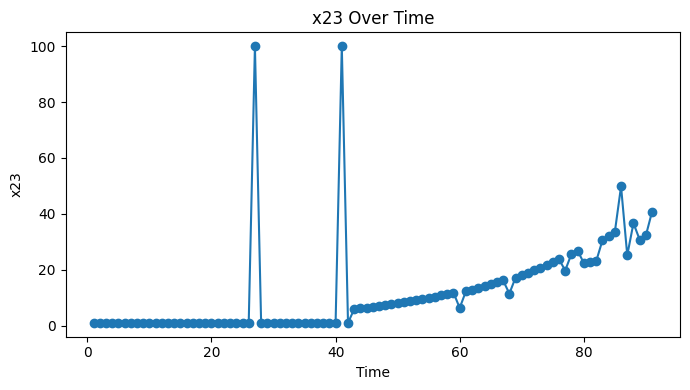

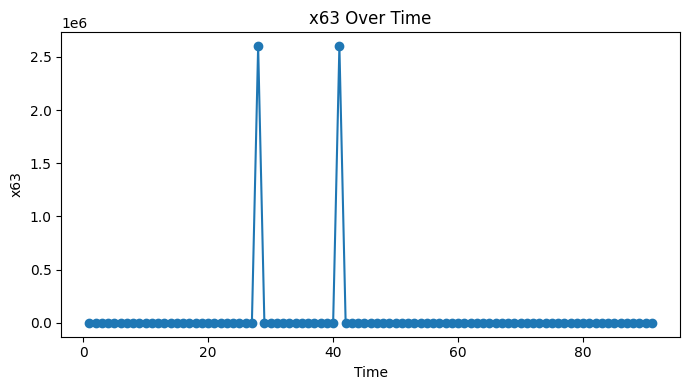

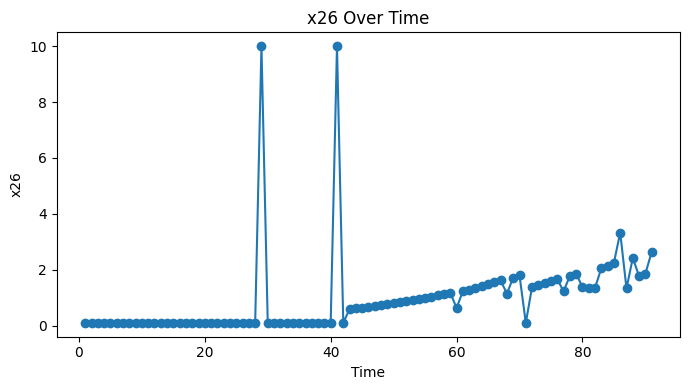

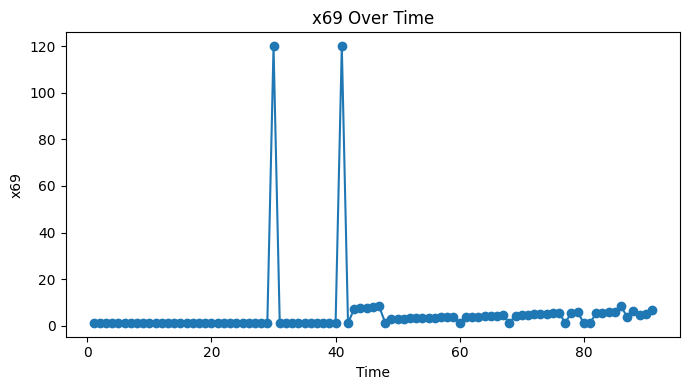

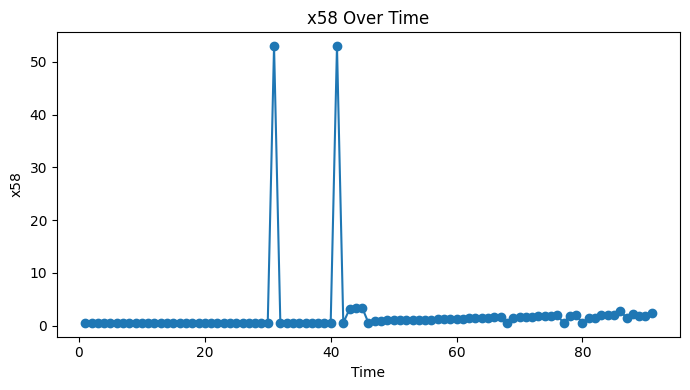

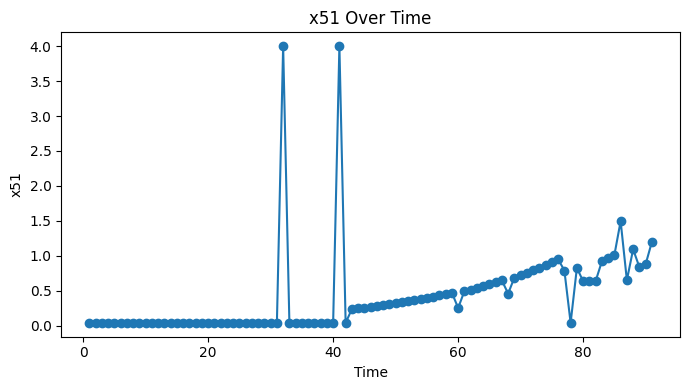

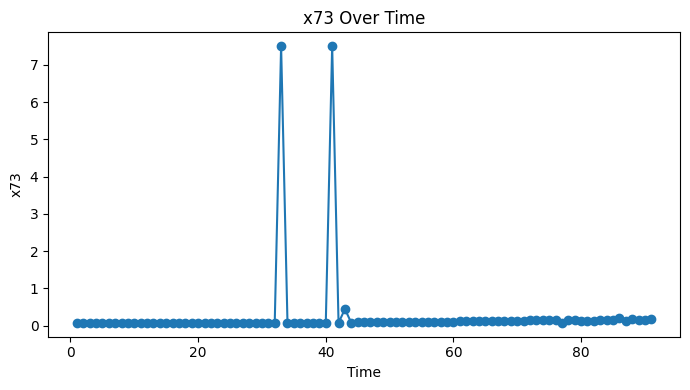

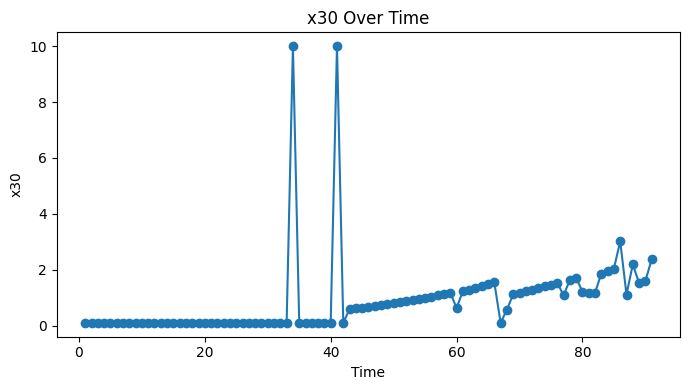

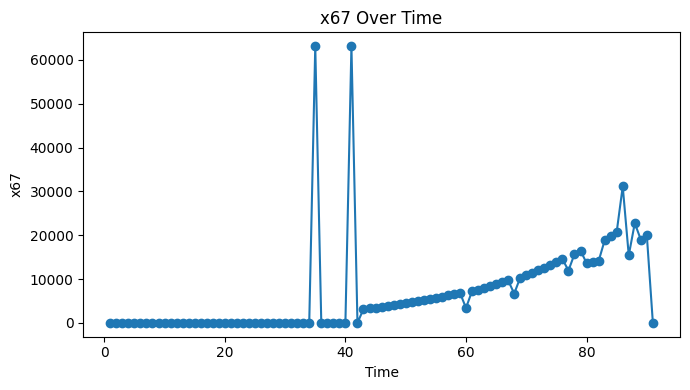

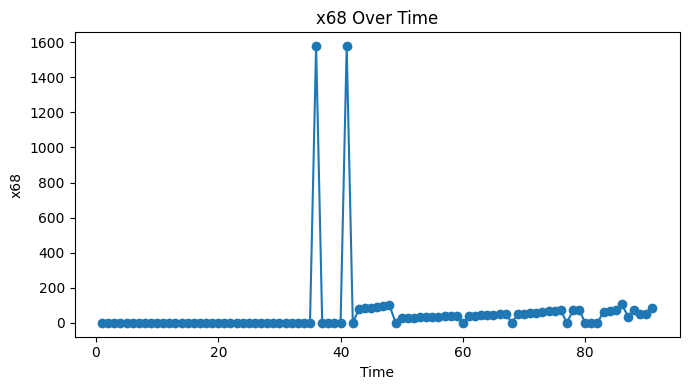

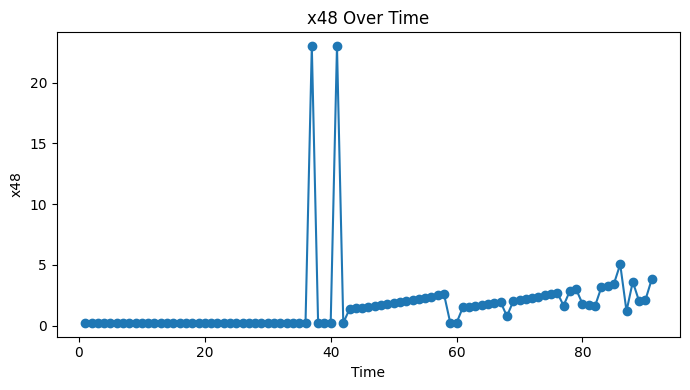

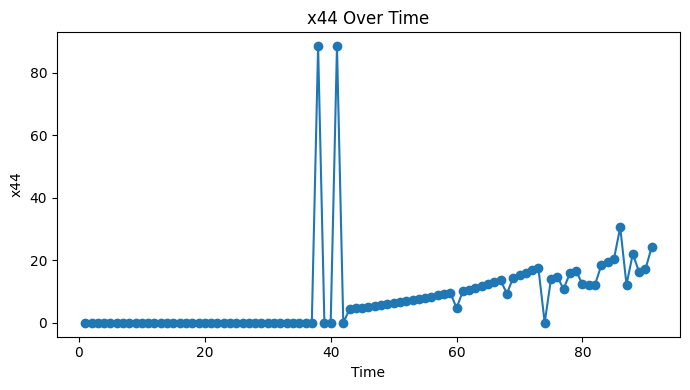

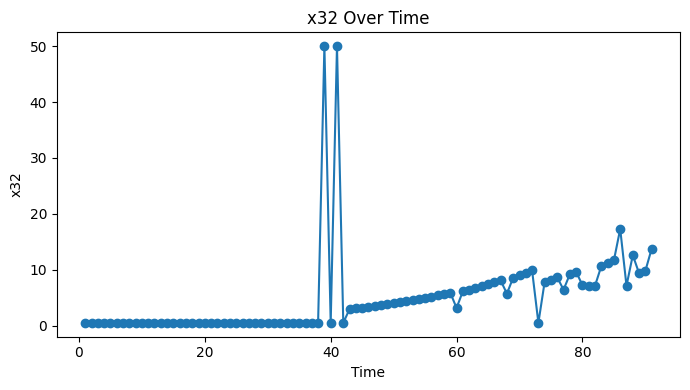

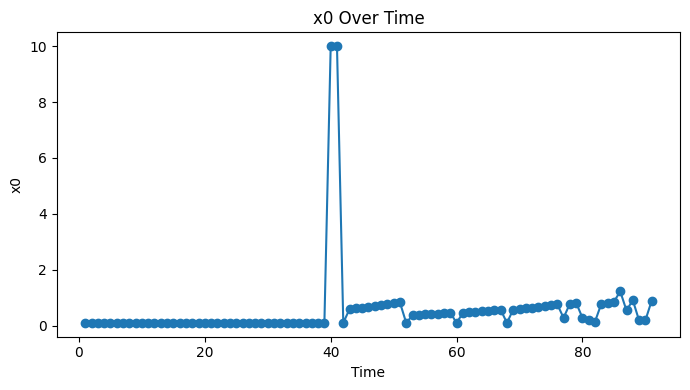

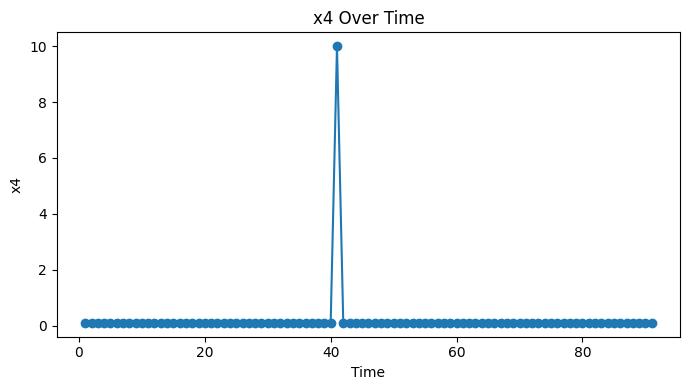

In [24]:
import matplotlib.pyplot as plt
output_df = output_df.reset_index(drop=True)

exclude = ['index', 'error']
params = [col for col in output_df.columns if col not in exclude]

for param in params:
    plt.figure(figsize=(7, 4))
    plt.plot(output_df['index'], output_df[param], marker='o')
    plt.xlabel('Time')
    plt.ylabel(param)
    plt.title(f'{param} Over Time')
    plt.tight_layout()
    plt.show()


## Error

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


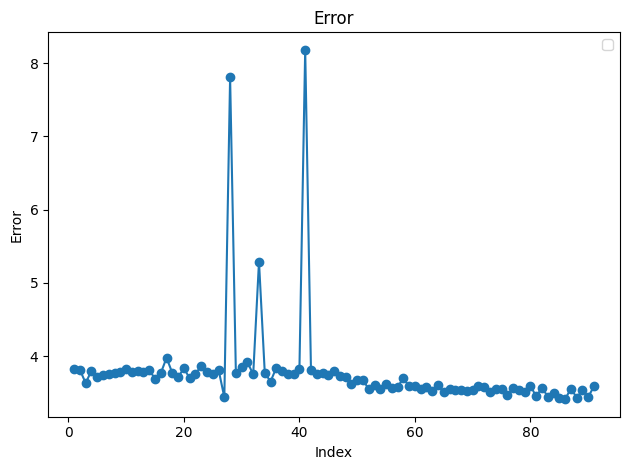

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('output.csv')

plt.plot(df['index'], df['error'], marker='o')

plt.xlabel('Index')
plt.ylabel('Error')
plt.title('Error')
plt.legend()
plt.tight_layout()
plt.show()